In [1]:
# ============================================================
# PHASE 3: Exploratory Data Analysis (EDA)
# Malaria Cell Classifier — Thrive Plus Capstone
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Dataset paths
PARASITIZED_PATH = 'malaria_data/cell_images/Parasitized'
UNINFECTED_PATH  = 'malaria_data/cell_images/Uninfected'

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# Run this if malaria_data folder is missing
import os

if not os.path.exists('malaria_data'):
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    os.system('cp kaggle.json /root/.config/kaggle/')
    os.system('chmod 600 /root/.config/kaggle/kaggle.json')
    os.system('pip install kaggle -q')
    os.system('kaggle datasets download -d iarunava/cell-images-for-detecting-malaria')

    import zipfile
    with zipfile.ZipFile('cell-images-for-detecting-malaria.zip', 'r') as zip_ref:
        zip_ref.extractall('malaria_data')
    print("Dataset re-downloaded ✅")
else:
    print("Dataset already available ✅")

Dataset re-downloaded ✅


In [3]:
# Analyze image dimensions across the dataset
def get_image_sizes(folder, sample_size=200):
    sizes = []
    files = [f for f in os.listdir(folder)
             if f.endswith('.png') or f.endswith('.jpg')][:sample_size]
    for f in files:
        try:
            img = Image.open(os.path.join(folder, f))
            sizes.append(img.size)  # (width, height)
        except:
            pass
    return sizes

para_sizes = get_image_sizes(PARASITIZED_PATH)
uninf_sizes = get_image_sizes(UNINFECTED_PATH)

all_sizes = para_sizes + uninf_sizes
widths  = [s[0] for s in all_sizes]
heights = [s[1] for s in all_sizes]

print("=" * 45)
print("   IMAGE SIZE ANALYSIS (sample of 400)")
print("=" * 45)
print(f"Width  — Min: {min(widths)}px  Max: {max(widths)}px  Avg: {int(np.mean(widths))}px")
print(f"Height — Min: {min(heights)}px  Max: {max(heights)}px  Avg: {int(np.mean(heights))}px")
print("=" * 45)
print("⚠️  Images are variable size — resizing needed in preprocessing")

   IMAGE SIZE ANALYSIS (sample of 400)
Width  — Min: 85px  Max: 217px  Avg: 132px
Height — Min: 73px  Max: 244px  Avg: 133px
⚠️  Images are variable size — resizing needed in preprocessing


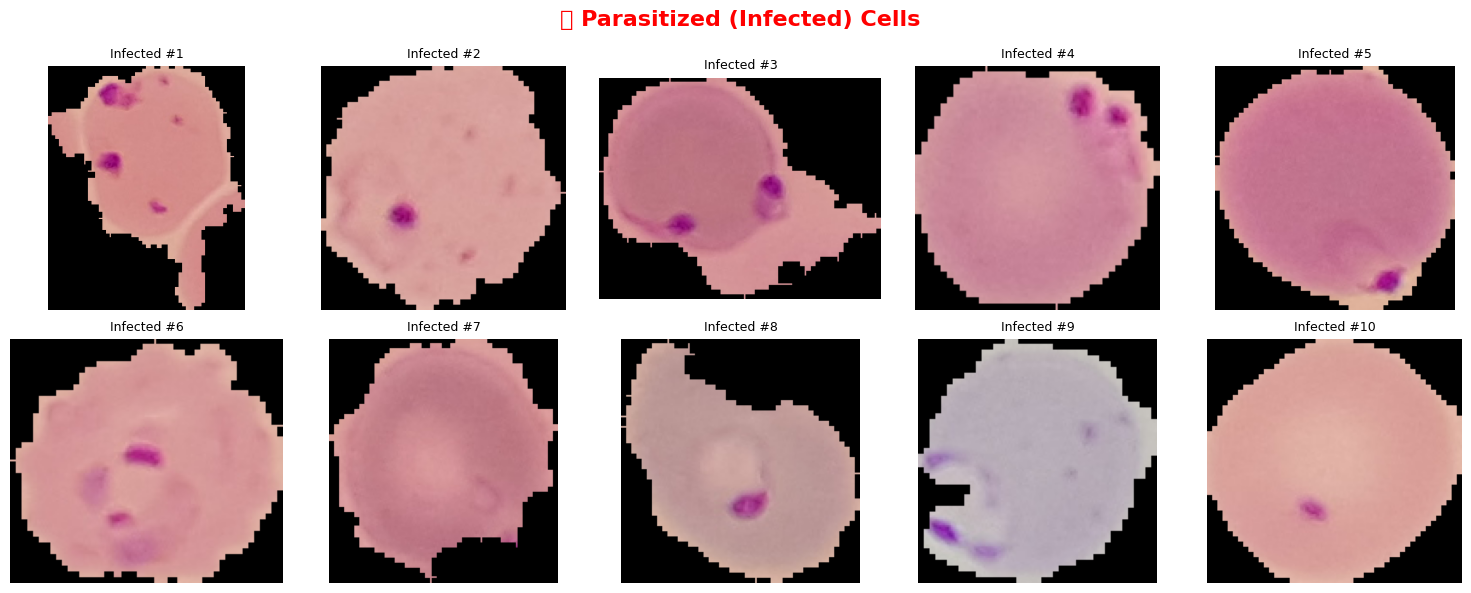

Parasitized samples visualized ✅


In [4]:
# Display 10 sample Parasitized (infected) cell images
para_files = [f for f in os.listdir(PARASITIZED_PATH)
              if f.endswith('.png') or f.endswith('.jpg')][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('🦟 Parasitized (Infected) Cells', fontsize=16, fontweight='bold', color='red')

for i, ax in enumerate(axes.flatten()):
    img = mpimg.imread(os.path.join(PARASITIZED_PATH, para_files[i]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Infected #{i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('results_parasitized_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Parasitized samples visualized ✅")

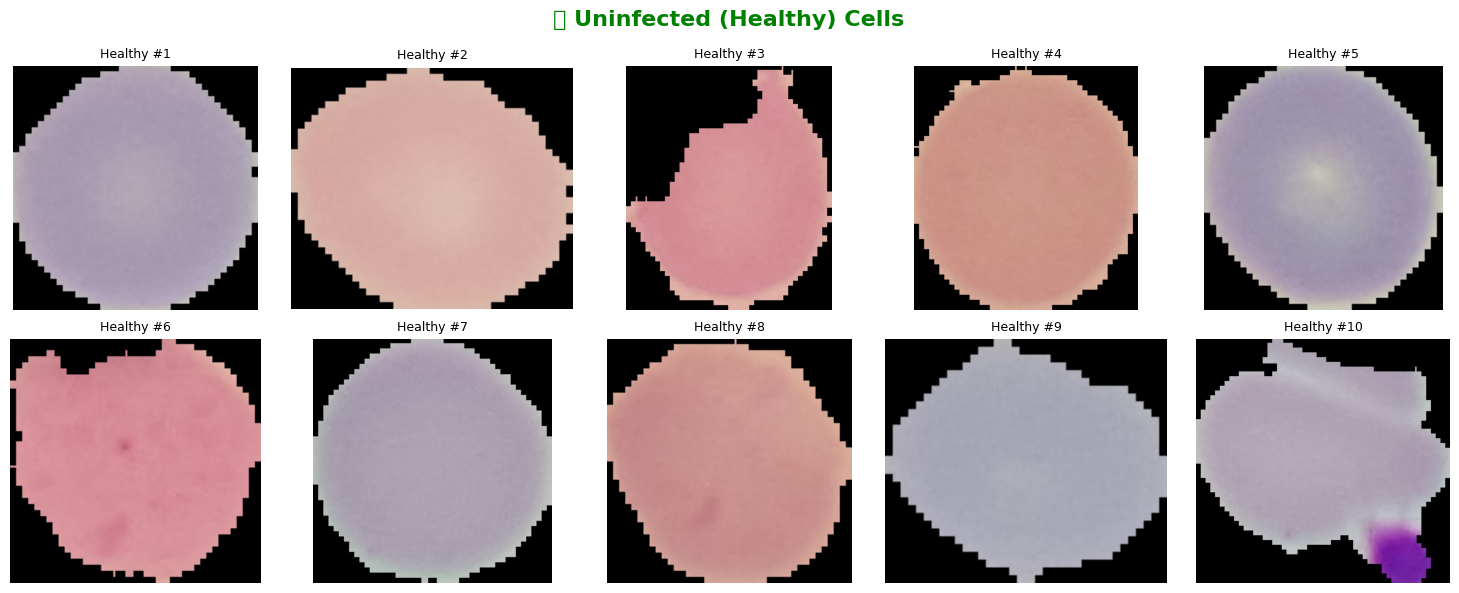

Uninfected samples visualized ✅


In [5]:
# Display 10 sample Uninfected cell images
uninf_files = [f for f in os.listdir(UNINFECTED_PATH)
               if f.endswith('.png') or f.endswith('.jpg')][:10]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('✅ Uninfected (Healthy) Cells', fontsize=16, fontweight='bold', color='green')

for i, ax in enumerate(axes.flatten()):
    img = mpimg.imread(os.path.join(UNINFECTED_PATH, uninf_files[i]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Healthy #{i+1}', fontsize=9)

plt.tight_layout()
plt.savefig('results_uninfected_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Uninfected samples visualized ✅")

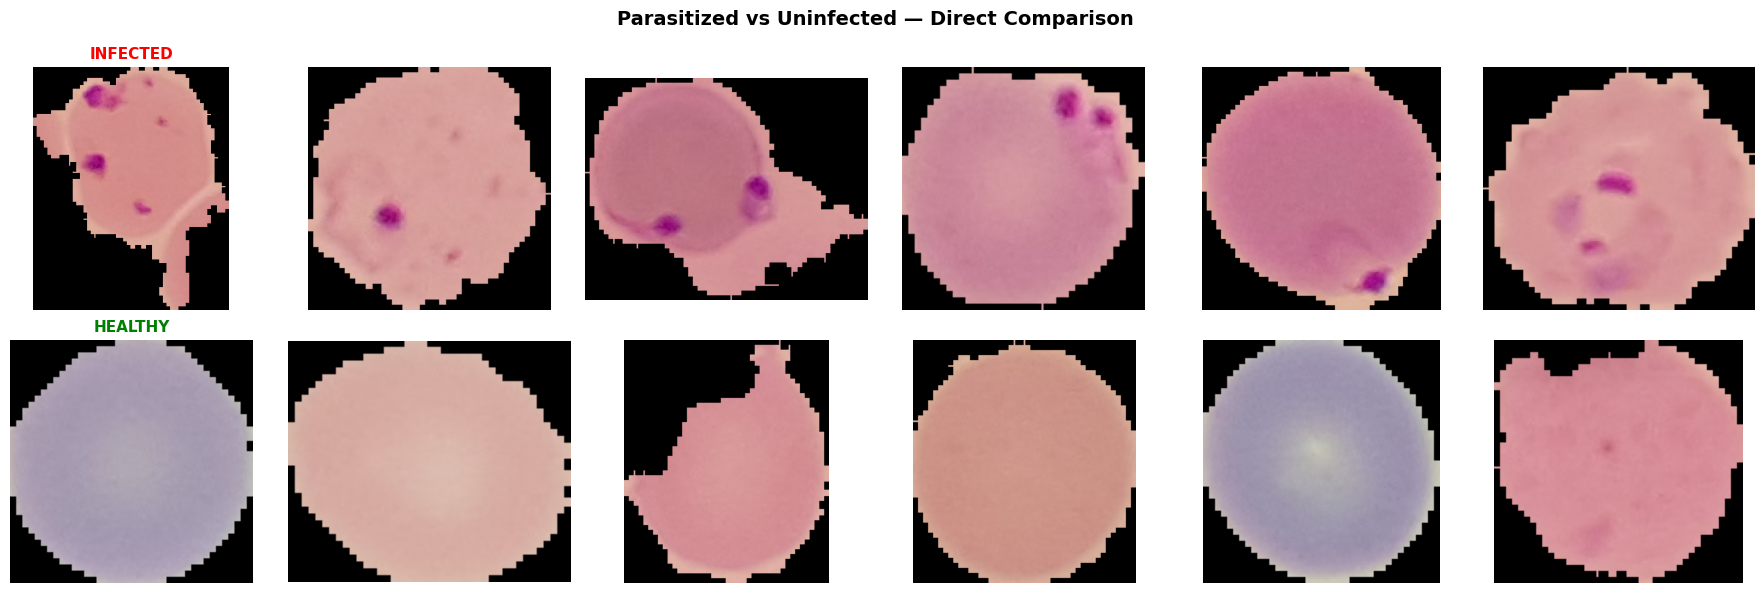

Comparison grid saved ✅


In [6]:
# Direct comparison: Infected vs Healthy
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Parasitized vs Uninfected — Direct Comparison',
             fontsize=14, fontweight='bold')

for i in range(6):
    # Top row: infected
    img_p = mpimg.imread(os.path.join(PARASITIZED_PATH, para_files[i]))
    axes[0, i].imshow(img_p)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('INFECTED', color='red', fontweight='bold', fontsize=11)

    # Bottom row: healthy
    img_u = mpimg.imread(os.path.join(UNINFECTED_PATH, uninf_files[i]))
    axes[1, i].imshow(img_u)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('HEALTHY', color='green', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison grid saved ✅")

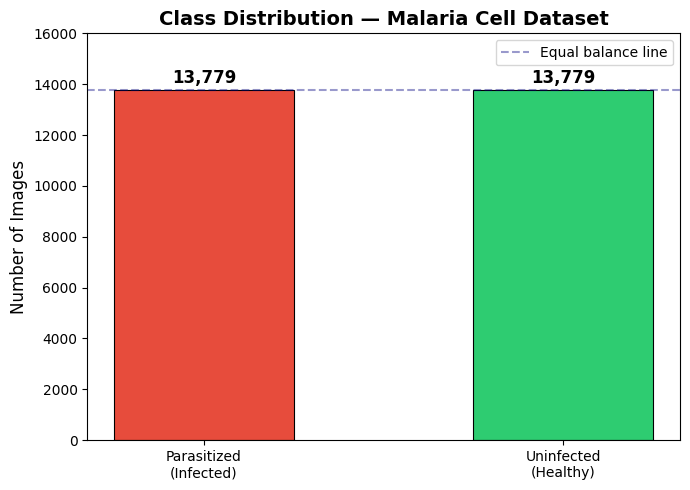

Class distribution chart saved ✅


In [7]:
# Class distribution bar chart
classes = ['Parasitized\n(Infected)', 'Uninfected\n(Healthy)']
counts  = [13779, 13779]
colors  = ['#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(classes, counts, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Class Distribution — Malaria Cell Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_ylim(0, 16000)
ax.axhline(y=13779, color='navy', linestyle='--', alpha=0.4, label='Equal balance line')
ax.legend()

plt.tight_layout()
plt.savefig('results_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution chart saved ✅")

In [8]:
print("""
╔══════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS             ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  1. DATASET BALANCE                              ║
║     • 13,779 infected + 13,779 healthy           ║
║     • Perfect 50/50 split — no imbalance         ║
║                                                  ║
║  2. IMAGE CHARACTERISTICS                        ║
║     • Variable sizes (~100–170px range)          ║
║     • RGB color images                           ║
║     • Microscope staining visible                ║
║                                                  ║
║  3. VISUAL DIFFERENCES                           ║
║     • Infected: dark purple spots (parasites)    ║
║     • Healthy: clean, uniform pink/red cells     ║
║                                                  ║
║  4. PREPROCESSING NEEDED                         ║
║     • Resize all images to 224x224px             ║
║     • Normalize pixel values                     ║
║     • Apply augmentation to improve robustness   ║
║                                                  ║
╚══════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS             ║
╠══════════════════════════════════════════════════╣
║                                                  ║
║  1. DATASET BALANCE                              ║
║     • 13,779 infected + 13,779 healthy           ║
║     • Perfect 50/50 split — no imbalance         ║
║                                                  ║
║  2. IMAGE CHARACTERISTICS                        ║
║     • Variable sizes (~100–170px range)          ║
║     • RGB color images                           ║
║     • Microscope staining visible                ║
║                                                  ║
║  3. VISUAL DIFFERENCES                           ║
║     • Infected: dark purple spots (parasites)    ║
║     • Healthy: clean, uniform pink/red cells     ║
║                                                  ║
║  4. PREPROCESSING NEEDED                         ║
║     • Resize all images to 224x224px       